In [1]:
%pip install qiskit==1.2.4
%pip install qiskit-aer==0.15.1
%pip install pylatexenc==2.10

from qiskit import QuantumCircuit
from qiskit.converters import circuit_to_gate
from qiskit.visualization import array_to_latex
from qiskit.quantum_info import Operator
from qiskit.quantum_info import Statevector
from qiskit import transpile
from qiskit.providers.basic_provider import BasicSimulator
from qiskit.visualization import plot_histogram

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip available: 22.3 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip available: 22.3 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip available: 22.3 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


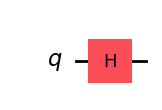

In [2]:

# Create a circuit with one qubit
# Creates 1 qubit that starts with |0⟩ state.
circuit = QuantumCircuit(1)

# Add a Hadamard (H) gate on qubit 0, to create a superposition
# circuit.h(0) means that instead of definitely 0, it is now either 0 or 1 with equal probability. The state is now (|0> + |1>)/sqrt(2).
# circuit.h(1) difference in phase. Difference |0⟩ + |1⟩ is same phase and |0⟩ − |1⟩ means opposite phase.
circuit.h(0)

# Draw the circuit diagram. Delete "mpl" to get a text diagram.
circuit.draw("mpl")

In [3]:
# Now simulate the circuit by calculating the effect on state vectors.
# Set the initial state of the simulator to |0>
# The state vector has two coefficients, both 0
# Creating dimensions of 4.

# Simpler Analogy
# [Apple, Banana]
# 2 -> 2 items, 0 -> Pick first item
state = Statevector.from_int(0, 2)

# Apply the circuit to the state
state = state.evolve(circuit)

# Display using latex. This requires the pylatexenc module.
# Omit "latex" to get a numerical (not algebraic) view of the state vector.
state.draw("latex")

<IPython.core.display.Latex object>

In [4]:
# A different way of dislaying the state, again using latex
from qiskit.visualization import array_to_latex

array_to_latex(state)

<IPython.core.display.Latex object>

In [5]:
# The whole circuit is a unitary operator, which we can display.

U = Operator(circuit)
array_to_latex(U)

<IPython.core.display.Latex object>

In [6]:
# Or less beautifully:
U.data
# The format is a little bit odd. 0.j means the imaginary part is 0
# 0 is being displayed with a decimal point but no trailing 0
# j is used for the square root of -1, instead of i

array([[ 0.70710678+0.j,  0.70710678+0.j],
       [ 0.70710678+0.j, -0.70710678+0.j]])

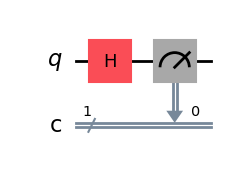

In [7]:
# Now reconstruct the circuit and add a measurement
# The second parameter of QuantumCircuit is the number of classical bits
circuit = QuantumCircuit(1,1)
circuit.h(0)

# The first list is the qubits to measure,
# the second list is the classical bits where the results go
circuit.measure([0],[0])
circuit.draw("mpl")

In [8]:
# We will need to transpile the circuit into QASM instructions for the back end

# Use BasicSimulator
backend = BasicSimulator()

# Compile / transpile
qc_compiled = transpile(circuit, backend)

# Run the circuit on the simulator.
# We've set the number of repeats of the circuit
# to be 1024, which is the default.
# The qubits start in state |0>
job_sim = backend.run(qc_compiled, shots=1024)

# Grab the results from the job (this doesn't produce any output).
result_sim = job_sim.result()

In [9]:
# The simplest way to see the results of the simulation
counts = result_sim.get_counts(qc_compiled)
print(counts)

# The results are not exactly half 0 and half 1, but should be close.
# There will be different results each time the previous cell is run.

{'0': 516, '1': 508}


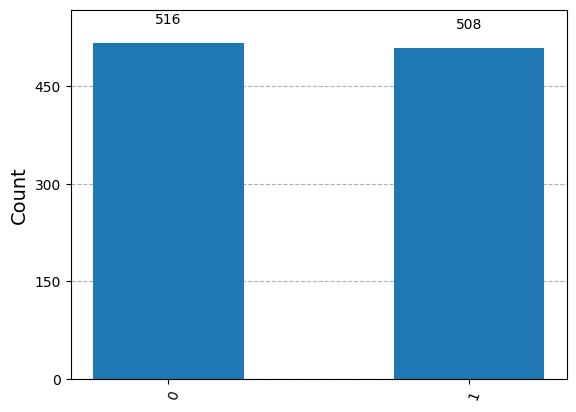

In [10]:
# We can also produce a graph

plot_histogram(counts)

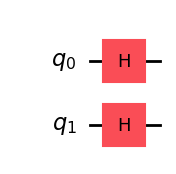

In [11]:
# Now let's move on to two qubits.
# Apply H to both qubits and see what we get.

circuit = QuantumCircuit(2)
circuit.h(0)
circuit.h(1)

circuit.draw("mpl")

In [12]:
state = Statevector.from_int(0, 4) # 4 is the number of basis states on 2 qubits
state = state.evolve(circuit)
state.draw("latex")

<IPython.core.display.Latex object>

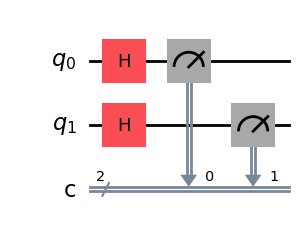

In [13]:
# Now measurement. This time we construct the measurement part
# of the circuit separately and then combine it with the first circuit.

# A new circuit with 2 qubits and 2 classical bits
meas = QuantumCircuit(2, 2)

# Map the quantum measurement to the classical bits
meas.measure(range(2), range(2))

# The Qiskit circuit object supports composition.
# Here the meas has to be first and front=True (putting it before)
# as compose must put a smaller circuit into a larger one.
qc = meas.compose(circuit, range(2), front=True)

qc.draw("mpl")

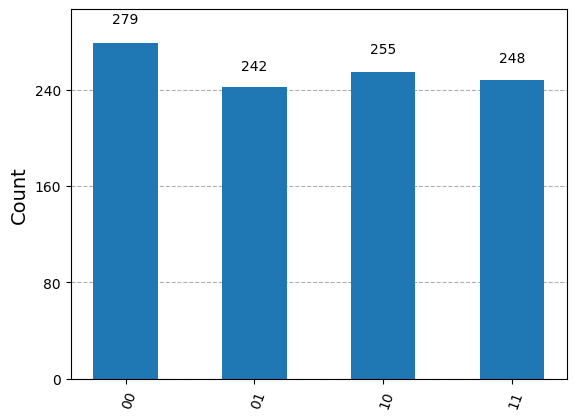

In [14]:
# Simulate again, using the same back end
qc_compiled = transpile(qc, backend)
job_sim = backend.run(qc_compiled, shots=1024)
result_sim = job_sim.result()
counts = result_sim.get_counts(qc_compiled)
plot_histogram(counts)

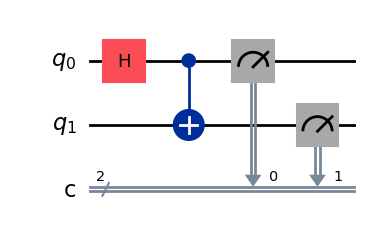

In [15]:
# Now for some entanglement.
# Construct a Bell state and measure both qubits to see that
# both measurements give the same result.

circuit = QuantumCircuit(2,2)
circuit.h(0)
circuit.cx(0,1) # cx means CNOT because it's a controlled version of x (negation)
circuit.measure(range(2),range(2))
circuit.draw("mpl")

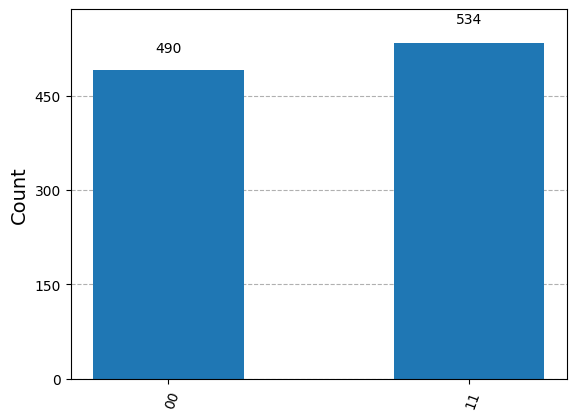

In [16]:
qc_compiled = transpile(circuit, backend)
job_sim = backend.run(qc_compiled, shots=1024)
result_sim = job_sim.result()
counts = result_sim.get_counts(qc_compiled)
plot_histogram(counts)

Phi+ = 1/sqrt(2) (|00> + |11>)


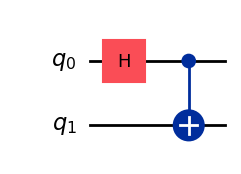

<IPython.core.display.Latex object>

Measurement results: {'00': 483, '11': 541}
Expected bit strings: 00 or 11


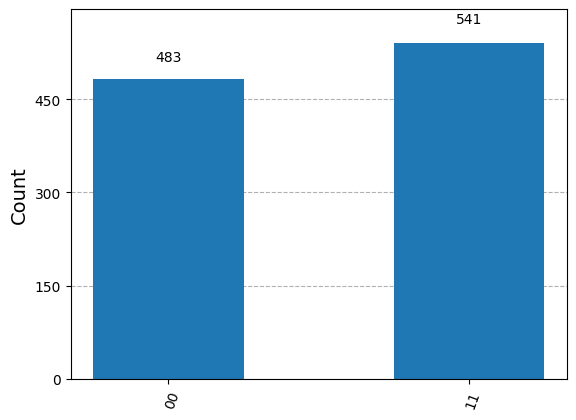


Phi- = 1/sqrt(2) (|00> - |11>)


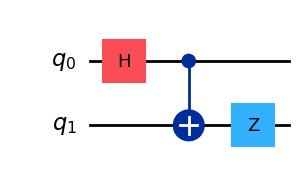

<IPython.core.display.Latex object>

Measurement results: {'11': 528, '00': 496}
Expected bit strings: 00 or 11


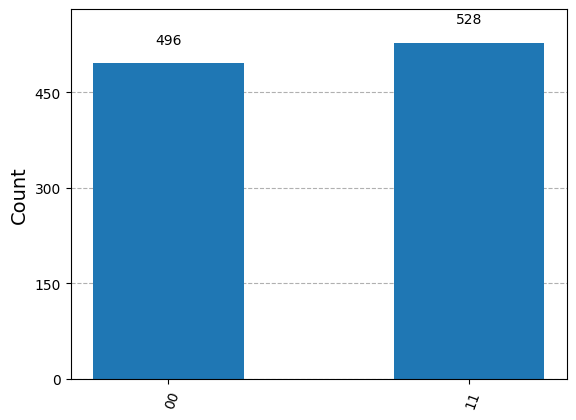


Psi+ = 1/sqrt(2) (|01> + |10>)


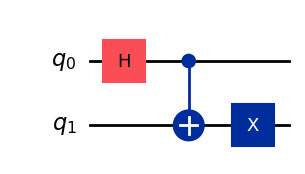

<IPython.core.display.Latex object>

Measurement results: {'01': 492, '10': 532}
Expected bit strings: 01 or 10


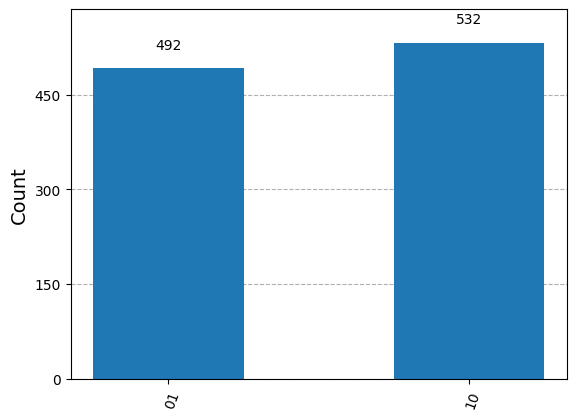


Psi- = 1/sqrt(2) (|01> - |10>)


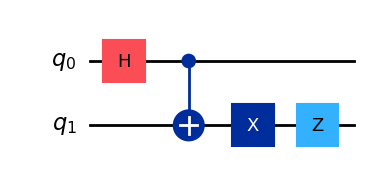

<IPython.core.display.Latex object>

Measurement results: {'10': 532, '01': 492}
Expected bit strings: 01 or 10


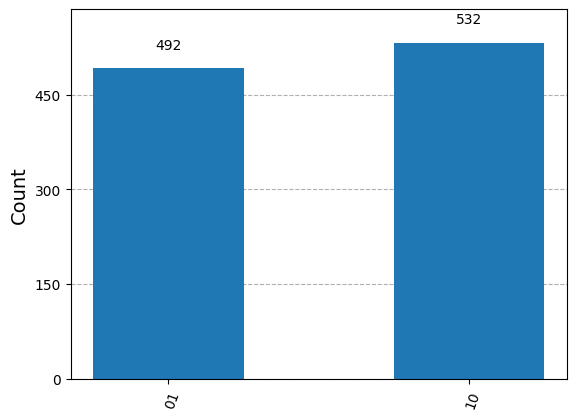

In [17]:
# EXERCISE

# Make a copy here of the circuit that creates the Bell state 1/sqrt(2) ( |00> + |11> ).

# Modify it to create the other Bell states: 1/sqrt(2) ( |00> - |11> ), 1/sqrt(2) ( |01> + |10> ), 1/sqrt(2) ( |01> - |10> ).

# You will need to use X and Z gates. Check that your circuit is correct by displaying the state vector in each case.

# For each of the Bell states, repeat the simulation with measurements and check that the results are as expected.

from IPython.display import display

def make_bell_circuit(use_x=False, use_z=False, measure=False):
    circuit = QuantumCircuit(2, 2) if measure else QuantumCircuit(2)

    circuit.h(0)
    circuit.cx(0, 1)

    if use_x:
        circuit.x(1)
    if use_z:
        circuit.z(1)

    if measure:
        circuit.measure(range(2), range(2))

    return circuit

bell_states = {
    "Phi+ = 1/sqrt(2) (|00> + |11>)": (False, False, "00 or 11"),
    "Phi- = 1/sqrt(2) (|00> - |11>)": (False, True, "00 or 11"),
    "Psi+ = 1/sqrt(2) (|01> + |10>)": (True, False, "01 or 10"),
    "Psi- = 1/sqrt(2) (|01> - |10>)": (True, True, "01 or 10"),
}

for label, (use_x, use_z, expected) in bell_states.items():
    circuit = make_bell_circuit(use_x=use_x, use_z=use_z)
    state = Statevector.from_int(0, 4).evolve(circuit)

    print(label)
    display(circuit.draw("mpl"))
    display(state.draw("latex"))

    measured_circuit = make_bell_circuit(use_x=use_x, use_z=use_z, measure=True)
    qc_compiled = transpile(measured_circuit, backend)
    job_sim = backend.run(qc_compiled, shots=1024)
    result_sim = job_sim.result()
    counts = result_sim.get_counts(qc_compiled)

    print("Measurement results:", counts)
    print("Expected bit strings:", expected)
    display(plot_histogram(counts))
    print()

# The plus and minus versions have the same measurement counts in the computational basis.
# The sign is a phase difference, so it is visible in the state vector but not in these measurements.

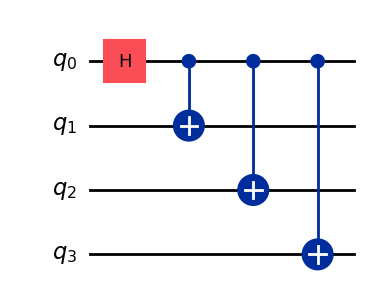

<IPython.core.display.Latex object>

Measurement results for 4 qubits: {'0000': 506, '1111': 518}
Expected bit strings: all 0s or all 1s


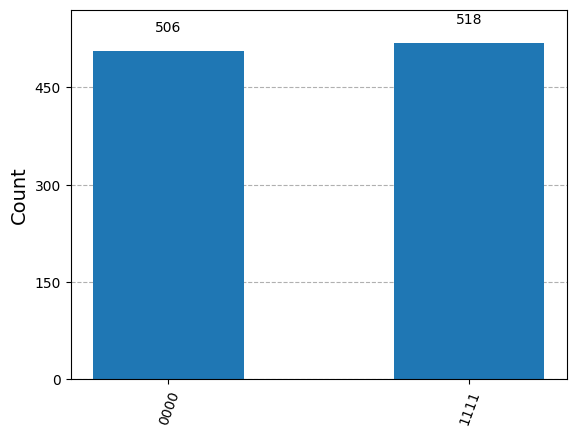


Benchmark with 128 shots
 2 qubits: 0.003 seconds, outcomes = ['00', '11']
 3 qubits: 0.002 seconds, outcomes = ['000', '111']
 5 qubits: 0.003 seconds, outcomes = ['00000', '11111']
10 qubits: 0.004 seconds, outcomes = ['0000000000', '1111111111']
15 qubits: 0.021 seconds, outcomes = ['000000000000000', '111111111111111']
20 qubits: 0.525 seconds, outcomes = ['00000000000000000000', '11111111111111111111']

On this backend, 20 qubits is still reasonable on this machine.
The BasicSimulator hard limit is 24 qubits; 24 is possible but much slower, and 25 is rejected.


In [18]:
# EXERCISE

# The GHZ state on any number of qubits has the form  1/sqrt(2) ( |00...0> + |11...1> )

# The Bell state 1/sqrt(2) ( |00> + |11> ) is the case for two qubits.

# Write code to construct a circuit that produces a GHZ state for any given number of qubits.

# Try simulating the circuit, with measurements. How many qubits can the simulator handle in a reasonable time?

from time import perf_counter

def make_ghz_circuit(num_qubits, measure=False):
    if num_qubits < 2:
        raise ValueError("A GHZ state needs at least two qubits.")

    circuit = QuantumCircuit(num_qubits, num_qubits) if measure else QuantumCircuit(num_qubits)

    circuit.h(0)
    for target in range(1, num_qubits):
        circuit.cx(0, target)

    if measure:
        circuit.measure(range(num_qubits), range(num_qubits))

    return circuit

# Example: a 4-qubit GHZ state.
num_qubits = 4
circuit = make_ghz_circuit(num_qubits)
display(circuit.draw("mpl"))

state = Statevector.from_int(0, 2 ** num_qubits).evolve(circuit)
display(state.draw("latex"))

measured_circuit = make_ghz_circuit(num_qubits, measure=True)
qc_compiled = transpile(measured_circuit, backend)
job_sim = backend.run(qc_compiled, shots=1024)
result_sim = job_sim.result()
counts = result_sim.get_counts(qc_compiled)

print("Measurement results for", num_qubits, "qubits:", counts)
print("Expected bit strings: all 0s or all 1s")
display(plot_histogram(counts))

# A quick benchmark. Larger GHZ circuits are slower because the state vector has 2**n amplitudes.
benchmark_sizes = [2, 3, 5, 10, 15, 20]
print("\nBenchmark with 128 shots")

for n in benchmark_sizes:
    measured_circuit = make_ghz_circuit(n, measure=True)
    start = perf_counter()
    qc_compiled = transpile(measured_circuit, backend)
    result_sim = backend.run(qc_compiled, shots=128).result()
    elapsed = perf_counter() - start
    counts = result_sim.get_counts(qc_compiled)
    print(f"{n:2d} qubits: {elapsed:.3f} seconds, outcomes = {sorted(counts)}")

print("\nOn this backend, 20 qubits is still reasonable on this machine.")
print("The BasicSimulator hard limit is", backend.MAX_QUBITS_MEMORY, "qubits; 24 is possible but much slower, and 25 is rejected.")